<pre><h1 align='center'style=color:blue>Machine learning</h1>
<h3> Types of Machine Learning </h3>
Supervised learning              Supervised learning            Reinforcement Learning
--> Regression                    --> Classification
  -Linear Regression                 -Logistic Regression
  -Polynomial Regression             -Naive bayes
  -Lasso(L1)                         -KNN
  -Ridge(L2)                         -SVM
</pre>

* Step of Machine Learning Procedure
  + Reading the dataset
  + clean the dataset & and Analysis
  + data Visualization or EDA
  + Using Encoding if required
  + Input and Output creation
  + Train Test split
  + Scaling : 
        - standard scaler(Standardization)
        - MinMax Scaler(Normalization)
  + ML Algorithm
  + Prediction
  + Evaluate The accuracy


In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
df = pd.read_csv('advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [104]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [105]:
df.shape

(200, 4)

In [106]:
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

<Axes: ylabel='Count'>

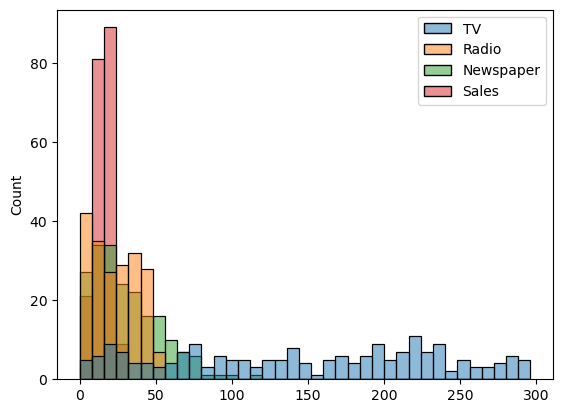

In [107]:
sns.histplot(df)

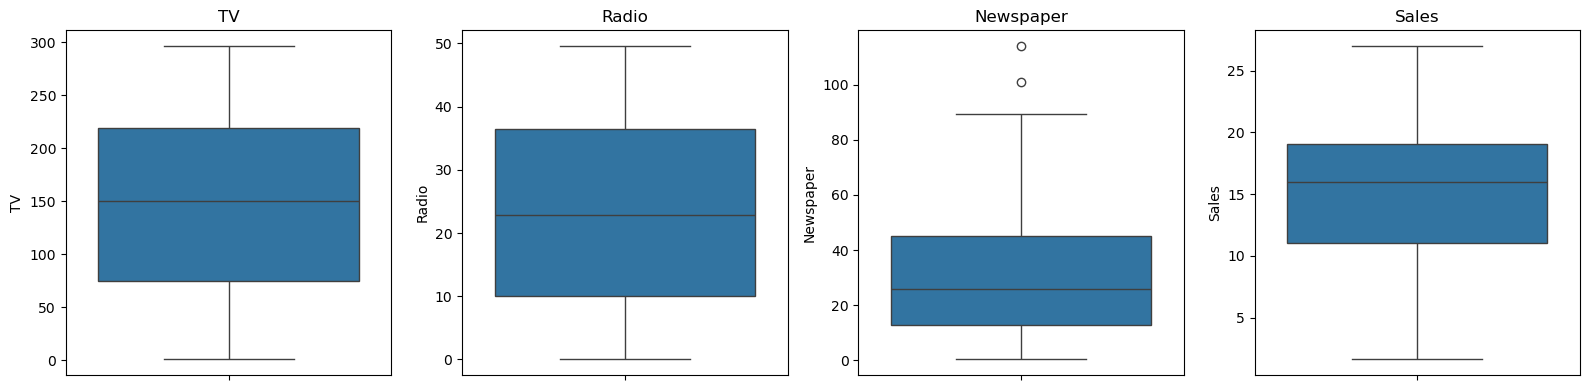

In [108]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, df.columns):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

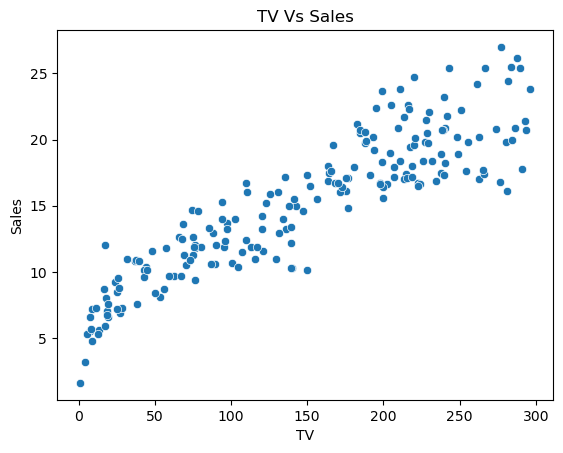

In [109]:
sns.scatterplot(x=df.TV,y=df.Sales)
plt.title('TV Vs Sales')
plt.show()

In [110]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

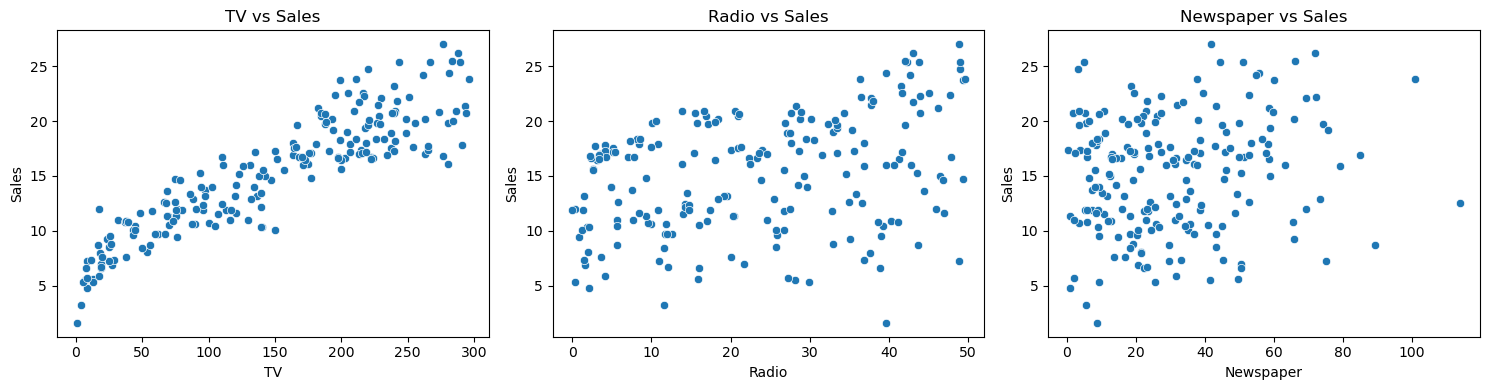

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, i in zip(axes, ['TV', 'Radio', 'Newspaper']):
    sns.scatterplot(x=df[i], y=df.Sales, ax=ax)
    ax.set_title(f'{i} vs Sales')

plt.tight_layout()
plt.show()

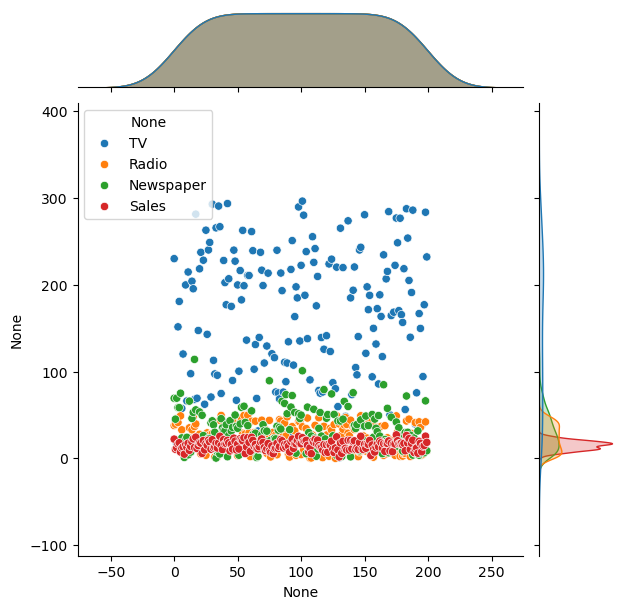

In [112]:
sns.jointplot(data=df)
plt.show()

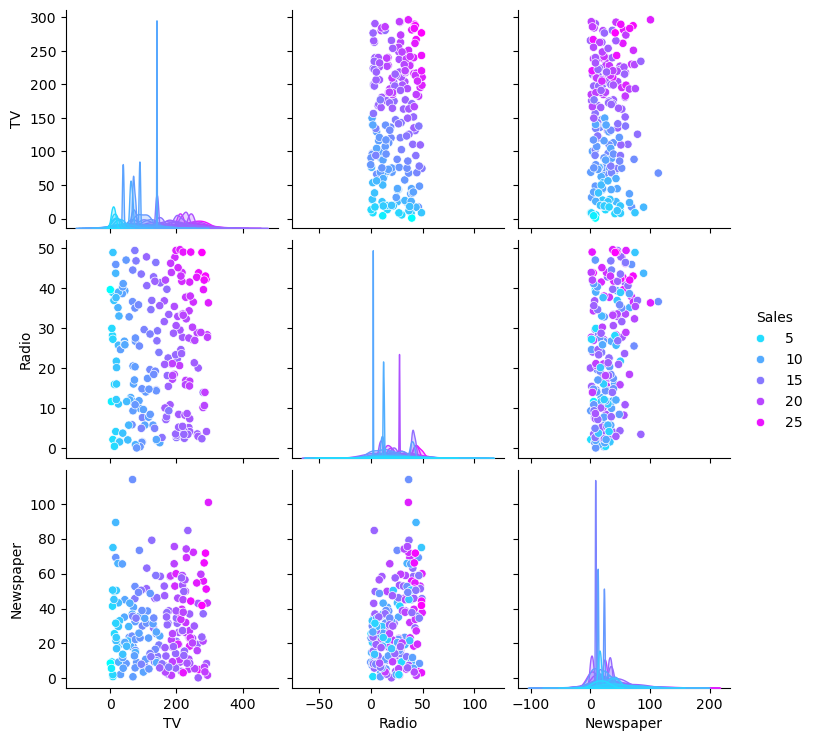

In [113]:
sns.pairplot(df,hue='Sales', palette='cool')
plt.show()

In [114]:
c = df.corr()
c

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


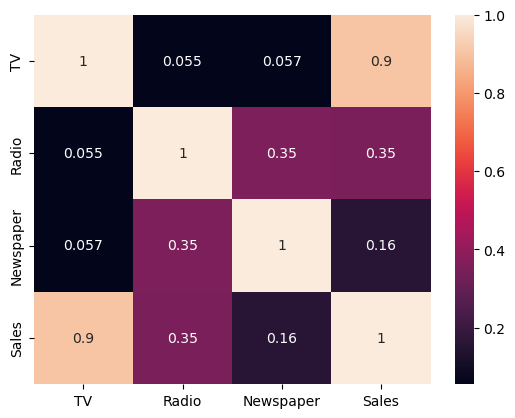

In [115]:
sns.heatmap(c,annot=True)
plt.show()

## Feature and Label creation


In [116]:
X = df.drop('Sales', axis=1)
y = df['Sales']

In [117]:
X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


## Train Test Split

In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

X_train.shape , X_test.shape

((160, 3), (40, 3))

In [119]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


## Scalling

In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [121]:
X_train

array([[-4.04248386e-01, -1.02823707e+00, -3.37675384e-01],
       [ 3.20607716e-01, -9.19827737e-01, -1.16143931e+00],
       [-1.27051084e+00,  2.59123702e-01,  2.54250789e-01],
       [-1.04235941e+00, -6.96233499e-01, -5.74445854e-01],
       [ 8.79103401e-01, -1.38734296e+00, -7.07629243e-01],
       [-1.32873699e+00, -1.29926038e+00, -7.96418169e-01],
       [-9.43731452e-01, -4.65863678e-01,  5.35415722e-01],
       [-3.23140256e-02,  6.94073782e-02, -5.34984109e-01],
       [-5.39713297e-01, -1.16374872e+00,  2.19721762e-01],
       [-8.75998996e-01,  3.13328366e-01, -6.87898371e-01],
       [-8.53421511e-01,  1.62101588e+00,  2.24654481e-01],
       [ 2.18414888e-01, -1.06889056e+00, -8.45745350e-01],
       [-1.67928215e+00,  1.76330312e+00,  2.22240532e+00],
       [-1.68997675e+00,  1.08574483e+00,  1.01882210e+00],
       [-8.74810708e-01, -1.49575229e+00, -7.47090988e-01],
       [-2.45017701e-01, -1.16374872e+00,  6.68075010e-02],
       [-9.10459368e-01, -3.98107848e-01

In [122]:
type(X_train)

numpy.ndarray

In [123]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## MinMax Scaler

In [124]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
X_train = mm.fit_transform(X_train)
X_test = mm.transform(X_test)


# Linear regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)

## Model Prediction

In [135]:
y_pred = lr.predict(X_test)
pred

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

In [136]:
y_test

95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
115    12.6
69     22.3
170     8.4
174    16.5
45     16.1
66     11.0
182     8.7
165    16.9
78      5.3
186    10.3
177    16.7
56      5.5
152    16.6
82     11.3
68     18.9
124    19.7
16     12.5
148    10.9
93     22.2
65     11.3
60      8.1
84     21.7
67     13.4
125    10.6
132     5.7
9      15.6
18     11.3
55     23.7
75      8.7
150    16.1
104    20.7
135    11.6
137    20.8
164    11.9
76      6.9
Name: Sales, dtype: float64

## Model Evaluation 

In [138]:
from sklearn.metrics import mean_squared_error,r2_score	

mse = mean_squared_error(y_test,y_pred)
r2 = round(r2_score(y_test, y_pred),2)

print(f'MSE = {mse}, R2_score = {r2}')

MSE = 2.9077569102710896, R2_score = 0.91


In [143]:
Error_pct = round((Error / y_test) * 100, 2)
df_1 = pd.DataFrame({'y_test': list(y_test), 'Predicted': y_pred, 'Error': Error, 'Error%': Error_pct})
df_1.head()

,y_test,Predicted,Error,Error%
95,16.9,17.034772,0.13,0.77
15,22.4,20.409740,-1.99,-8.88
30,21.4,23.723989,2.32,10.84
158,7.3,9.272785,1.97,26.99
128,24.7,21.682719,-3.02,-12.23


## Linear Model plot

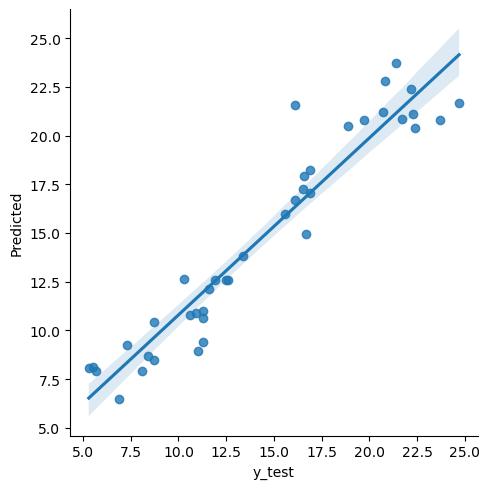

In [144]:
sns.lmplot(x='y_test' , y='Predicted', data=df_1, scatter_kws={'color':'g'}, line_kws=)